<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Logo-gustave-roussy.jpg/1200px-Logo-gustave-roussy.jpg" alt="Logo 1" width="250"/>
  <img src="https://upload.wikimedia.org/wikipedia/en/thumb/3/3f/Qube_Research_%26_Technologies_Logo.svg/1200px-Qube_Research_%26_Technologies_Logo.svg.png" alt="Logo 2" width="200" style="margin-left: 20px;"/>
</p>

# Data Challenge : Leukemia Risk Prediction

- OUTCOME:
  * OS_YEARS = Overall survival time in years
  * OS_STATUS = 1 (death) , 0 (alive at the last follow-up)

- CLINICAL DATA, with one line per patient:
  
  * ID = unique identifier per patient
  * CENTER = clinical center
  * BM_BLAST = Bone marrow blasts in % (blasts are abnormal blood cells)
  * WBC = White Blood Cell count in Giga/L 
  * ANC = Absolute Neutrophil count in Giga/L
  * MONOCYTES = Monocyte count in Giga/L
  * HB = Hemoglobin in g/dL
  * PLT = Platelets coutn in Giga/L
  * CYTOGENETICS = A description of the karyotype observed in the blood cells of the patients, measured by a cytogeneticist. Cytogenetics is the science of chromosomes. A karyotype is performed from the blood tumoral cells. The convention for notation is ISCN (https://en.wikipedia.org/wiki/International_System_for_Human_Cytogenomic_Nomenclature). Cytogenetic notation are: https://en.wikipedia.org/wiki/Cytogenetic_notation. Note that a karyotype can be normal or abnornal. The notation 46,XX denotes a normal karyotype in females (23 pairs of chromosomes including 2 chromosomes X) and 46,XY in males (23 pairs of chromosomes inclusing 1 chromosme X and 1 chromsome Y). A common abnormality in the blood cancerous cells might be for exemple a loss of chromosome 7 (monosomy 7, or -7), which is typically asssociated with higher risk disease

- GENE MOLECULAR DATA, with one line per patient per somatic mutation. Mutations are detected from the sequencing of the blood tumoral cells. 
We call somatic (= acquired) mutations the mutations that are found in the tumoral cells but not in other cells of the body.

  * ID = unique identifier per patient
  * CHR START END = position of the mutation on the human genome
  * REF ALT = reference and alternate (=mutant) nucleotide
  * GENE = the affected gene
  * PROTEIN_CHANGE = the consequence of the mutation on the protei that is expressed by a given gene
  * EFFECT = a broad categorization of the mutation consequences on a given gene.
  * VAF = Variant Allele Fraction = it represents the **proportion** of cells with the deleterious mutations. 

## The desired output

The C-index measures how well a predictive model can correctly order survival times. It calculates the proportion of all comparable pairs of individuals for which the model's predicted death risks are in the correct order relative to their actual survival times.

For example, a patient $j$ who died at time $T_j$ cannot form a "comparable" pair with a patient $i$ who survived up to a time $T_i < T_j$, because it is unknown whether patient $i$ would have survived until $T_j$.

However, it can be determined that patient $j$ survived longer than all patients $i$ who died before $T_j$ ($T_i < T_j$). It can also be determined that patient $j$ died before all patients who survived or died at a time later than $T_j$ ($T_i > T_j$).

For a "comparable" pair of patients i and j with $T_i < T_j$, the pair is considered concordant if the predicted death risks by the model are in the correct order: $R_i > R_j$.

Among all these pairs, the C-index calculates the number of correctly ordered pairs divided by the total number of pairs:

$C = \frac{\text{Number of Concordant Pairs}}{\text{Total Number of Comparable Pairs}}$

For a model with survival predictions, the C-index ranges between 0 and 1.

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

Importation des données

In [3]:
df = pd.read_csv("X_train/clinical_train.csv")
df_eval = pd.read_csv("X_test/clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("X_train/molecular_train.csv")
maf_eval = pd.read_csv("X_test/molecular_test.csv")

target_df = pd.read_csv("./target_train.csv")

In [4]:
df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


In [5]:
maf_df.head()

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0


So in a nutshell \
We train the model with X_train (mollecular and clinical ) and our Y is target_train.csv\
Our submission will be on the X_test and an example of submission is in the files

### Random forests

In [7]:
# Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

#Simplistic approach to Cytogentics 
#if the first two caracters are 46 we give type 1 if not type 0 and type 1 should be healthier than type 0

df['Is_normal'] = df['CYTOGENETICS'].fillna('').astype(str).str.startswith('46').astype(int)
df_eval['Is_normal'] = df_eval['CYTOGENETICS'].fillna('').astype(str).str.startswith('46').astype(int)

# Select features
features = ['BM_BLAST', 'HB', 'PLT','MONOCYTES','WBC',"ANC",'Is_normal']
target = ['OS_YEARS', 'OS_STATUS']

# Create the survival data format
df_eval_2 = df_eval.drop(columns=['CYTOGENETICS','CENTER','ID'])
df_eval_2 =df_eval_2[features]
X = df.loc[df['ID'].isin(target_df['ID']), features]


y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

OS_STATUS       bool
OS_YEARS     float64
dtype: object


In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
# Survival-aware imputation for missing values
imputer = SimpleImputer(strategy="median")
X_train[features] = imputer.fit_transform(X_train[features])
X_test[features] = imputer.transform(X_test[features])

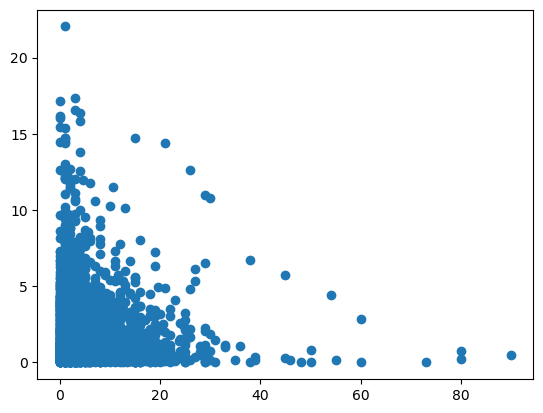

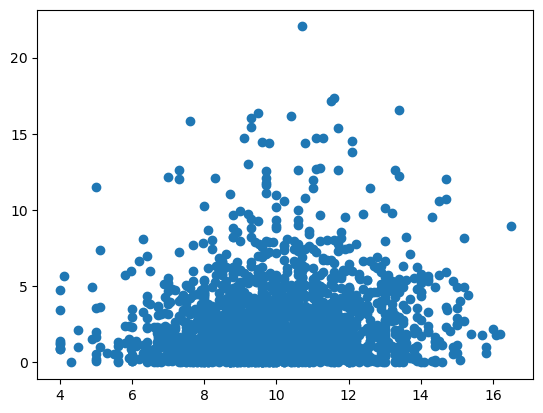

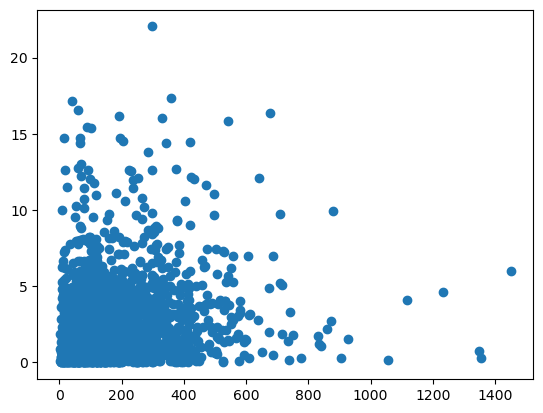

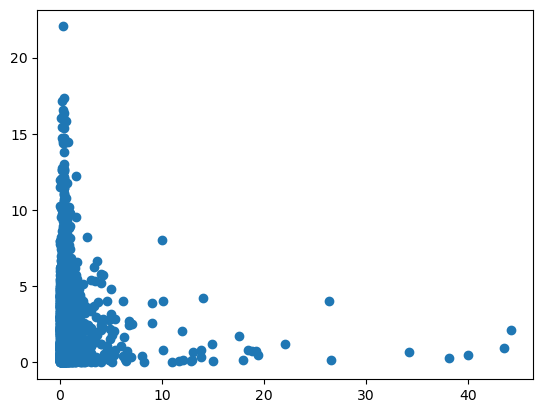

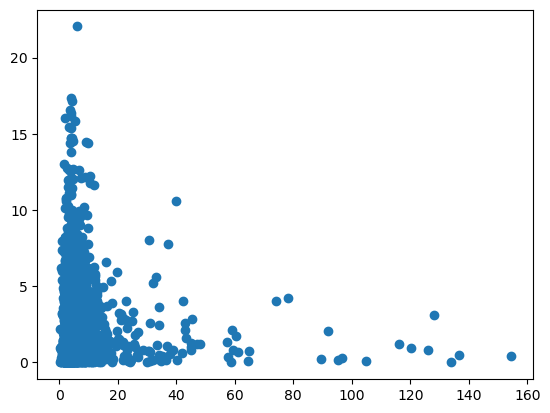

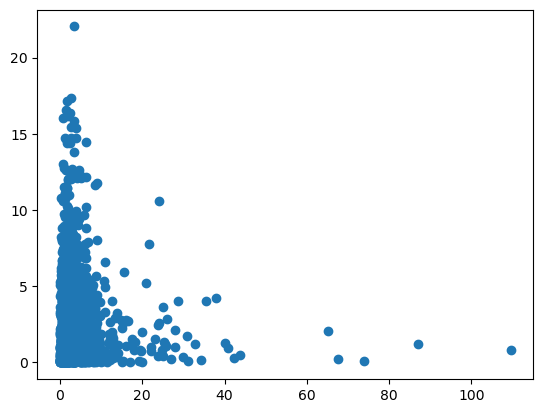

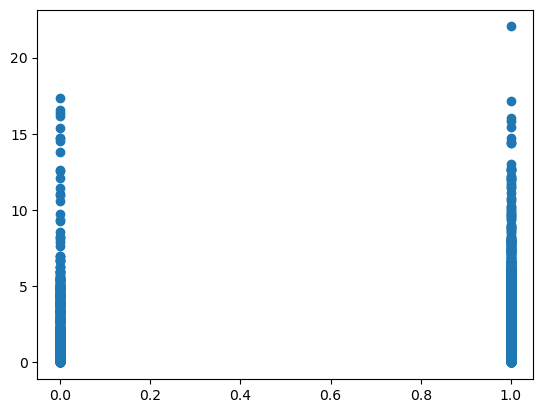

In [10]:
#let's visualiza our data
y_train_os_years = [y_train[i][1] for i in range(len(y_train))]
for feature in features:
    plt.scatter(X_train[feature],y_train_os_years)
    plt.show()

In [ ]:
somme_normal = 0
compteur_somme_normal = 0
somme_anormal = 0
compteur_somme_anormal = 0

# Parcourir les indices réels du DataFrame
for i in range(len(X_train)):  
    if X_train["Is_normal"].iloc[i] == 1:
        somme_normal += y_train_os_years[i]
        compteur_somme_normal += 1
    else:
        somme_anormal += y_train_os_years[i]
        compteur_somme_anormal += 1

# Affichage des résultats
print(f"Espérance de vie moyenne des génotypes normaux : {somme_normal / compteur_somme_normal}")
print(f"Espérance de vie moyenne des génotypes anormaux : {somme_anormal / compteur_somme_anormal}")

Espérance de vie moyenne des génotypes normaux : 2.6093361433087434
Espérance de vie moyenne des génotypes anormaux : 2.122272190330134


On a 0.5 de différence

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Create the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train_os_years)

# Predict on the training set
y_pred_train = rf_model.predict(X_train)

# Evaluate the model
mse = mean_squared_error(y_train_os_years, y_pred_train)
print(f"Training Mean Squared Error: {mse:.4f}")

Training Mean Squared Error: 0.9865


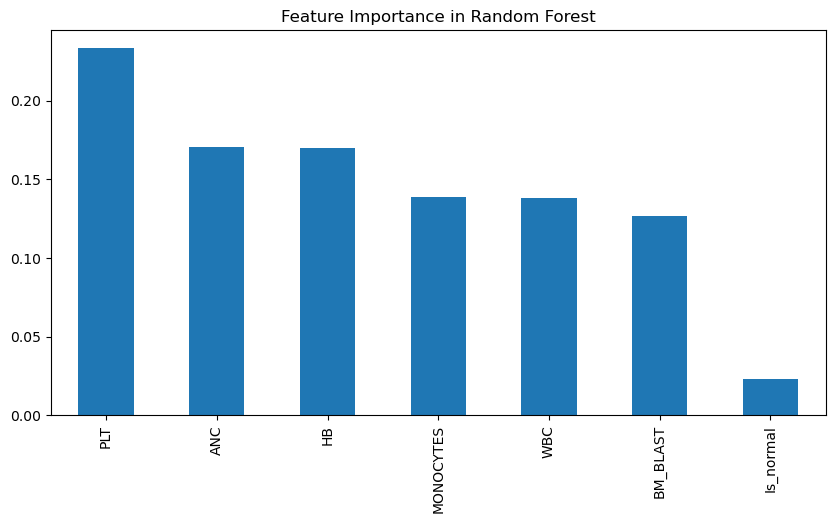

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Plot feature importance
feature_importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance in Random Forest")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [1000, 2000],
    'max_depth': [None, 10 , 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_gamma_deviance')
grid_search.fit(X_train, y_train_os_years)

print(f"Best parameters: {grid_search.best_params_}")


c:\aa_Perso\code\Lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\aa_Perso\code\Lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\aa_Perso\code\Lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\aa_Perso\code\Lib\site-packages\sklearn\metrics\_scorer.py", line 350, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\aa_Perso\code\Lib\si

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Create the model
rf_model = RandomForestRegressor(max_depth=10,min_samples_leaf=2,min_samples_split=5, n_estimators=2000, random_state=42)

# Train the model
rf_model.fit(X_train, y_train_os_years)

# Predict on the training set
y_pred_train = rf_model.predict(X_train)

# Evaluate the model
mse = mean_squared_error(y_train_os_years, y_pred_train)
print(f"Training Mean squarred error: {mse:.4f}")

Training Mean Gamma deviance: 2.9453


In [18]:
prediction_on_test_set = rf_model.predict(df_eval_2)

In [34]:
submission = pd.Series(prediction_on_test_set, index=df_eval['ID'], name='OS_YEARS')
submission

ID
KYW1       1.186729
KYW2       1.581552
KYW3       1.388636
KYW4       1.170116
KYW5       1.849185
             ...   
KYW1189    1.924904
KYW1190    1.924904
KYW1191    1.924904
KYW1192    1.924904
KYW1193    1.924904
Name: OS_YEARS, Length: 1193, dtype: float64

Let's now impliment the risk score

In [39]:
risk_score = (submission.max() - submission) / (submission.max() - submission.min())

# Convert to DataFrame if needed
submission_df = pd.DataFrame({"OS_YEARS": submission, "risk_score": risk_score})

submission_df = submission_df.drop(columns='OS_YEARS')
print(submission_df)

         risk_score
ID                 
KYW1       0.870346
KYW2       0.800724
KYW3       0.834742
KYW4       0.873276
KYW5       0.753531
...             ...
KYW1189    0.740179
KYW1190    0.740179
KYW1191    0.740179
KYW1192    0.740179
KYW1193    0.740179

[1193 rows x 1 columns]


In [40]:
submission_df.to_csv('./benchmark_submission.csv')

We have a score of 0.6493 which is below the benchmark it's high time to try a less naive approach

## IPCW-C-index

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
import pandas as pd
from sklearn import set_config
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from sksurv.datasets import load_flchain, load_gbsg2
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    concordance_index_ipcw,
    cumulative_dynamic_auc,
    integrated_brier_score,
)
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.preprocessing import OneHotEncoder, encode_categorical
from sksurv.util import Surv

We have this from the benchmark

In [ ]:
cox = CoxPHSurvivalAnalysis(n_iter=1000,verbose=1,tol=1e-15)
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.4f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.4f}")

iter      9: optimization converged
Cox Proportional Hazard Model Concordance Index IPCW on train: 0.6734
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.6634


In [16]:
cox = CoxnetSurvivalAnalysis(max_iter=10000000,verbose=1,tol=1e-15)
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.4f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.4f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 0.6740
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.6642


Let's add the molecular data